In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from PIL import Image

# Camera selection.
#
# Every USB camera registers TWO /dev/video* nodes: a capture node and a
# metadata node that cannot stream (sysfs "index" = 0 and 1). Minor numbers are
# handed out in plug order, so they shift whenever you replug - the C270 was
# video4, the Dino-Lite came up as video5. Don't hardcode a number; match the
# device name instead. Substring, case-insensitive; None = first camera found.
CAM_NAME = "dino"          # "dino", "c270", "acer", or None

def list_cameras():
    """[(index, name)] for every V4L2 capture node (metadata nodes excluded)."""
    found = []
    for path in sorted(glob.glob("/sys/class/video4linux/video*")):
        try:
            with open(os.path.join(path, "index")) as f:
                if int(f.read()) != 0:          # 1 = metadata node, can't stream
                    continue
            with open(os.path.join(path, "name")) as f:
                found.append((int(os.path.basename(path)[5:]), f.read().strip()))
        except OSError:
            continue
    return found

_last_cap = []          # release stale handles: a cell interrupted before
                        # cap.release() leaves a VideoCapture bound to a node
                        # that may vanish on replug ("failed VIDIOC_REQBUFS:
                        # errno=19 No such device" from the old object).

def open_camera(name=None, index=None):
    """Open a camera by name substring (default CAM_NAME), or by explicit index."""
    while _last_cap:
        _last_cap.pop().release()
    cameras = list_cameras()
    if index is None:
        want = CAM_NAME if name is None else name
        matches = [i for i, n in cameras if want is None or want.lower() in n.lower()]
        if not matches:
            raise RuntimeError("no camera matching {0!r}; found {1}".format(want, cameras))
        index = matches[0]

    cap = cv2.VideoCapture(index, cv2.CAP_V4L2)   # pinned: no silent FFMPEG fallback
    if cap.isOpened() and cap.read()[0]:
        print("opened /dev/video{0}: {1}".format(index, dict(cameras).get(index, "?")))
        _last_cap.append(cap)
        return cap
    cap.release()
    raise RuntimeError("/dev/video{0} won't stream (already open in another cell?); "
                       "capture nodes: {1}".format(index, cameras))

list_cameras()

[(0, 'ACER FHD User Facing: ACER FHD'), (2, 'ACER FHD User Facing: ACER IR U')]

# 1: camera intrinsics calibration

In [2]:
# ChArUco board:
COLS, ROWS = 6, 8                       # squares across, down
square_len = 0.03                      # 30 mm squares, in metres
marker_len = 0.0225                     # 22.5 mm markers (must be < square)
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_100)
board = cv2.aruco.CharucoBoard((COLS, ROWS), square_len, marker_len, aruco_dict)
MARGIN = 60
cv2.imwrite("charuco_6x8.png", board.generateImage((960 + 2 * MARGIN, 1280 + 2 * MARGIN), marginSize=MARGIN))

True

In [3]:
def calibrate_camera_intrinsic(image_filenames):
    detector = cv2.aruco.CharucoDetector(board)   # sub-pixel refines internally
    all_obj, all_img = [], []
    image_resolution = None

    for img_file in sorted(image_filenames):
        img = cv2.imread(img_file)
        if img is None:
            print("=> unreadable: {0}".format(img_file))
            continue
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        wh = img_gray.shape[:2][::-1]   # converts numpy (h, w) to (w, h)
        if image_resolution is None:
            image_resolution = wh
        elif wh != image_resolution:
            raise ValueError("{0}: size {1} != {2}".format(img_file, wh, image_resolution))

        corners, ids, _, _ = detector.detectBoard(img_gray)
        n = 0 if corners is None else len(corners)

        if n < 6:                       # too few (or none) to pose the board - skip
            continue
        
        objPoints, imgPoints = board.matchImagePoints(corners, ids)
        all_obj.append(objPoints)
        all_img.append(imgPoints)

    if len(all_obj) < 4:
        raise RuntimeError("only {0} usable views; aim for 20+".format(len(all_obj)))

    # Default 5-coefficient model (k1,k2,p1,p2,k3). CALIB_RATIONAL_MODEL adds 3
    # more radial terms but overfits unless many views reach the image border.
    (ret, camera_matrix, distortion_coefficients,
     rotation_vectors, translation_vectors) = cv2.calibrateCamera(
        all_obj, all_img, image_resolution, None, None)

    print('views used:', len(all_obj))
    print('ret (RMS reprojection, px):', ret)   # want < 0.5
    print('camera_matrix:', camera_matrix)
    print('distortion_coefficients:', distortion_coefficients.ravel())
    return True, camera_matrix, distortion_coefficients

def detect_calib_board(image_rgb, camera_matrix, dist_coeffs):
    output_img_rgb = image_rgb.copy()
    grey = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    detector = cv2.aruco.CharucoDetector(board)
    corners, chIds, mCorners, mIds = detector.detectBoard(grey)
    if corners is None or len(corners) < 4:
        print('Error: Could not identify the calibration board in the image!')
        return False, None, None, output_img_rgb

    # OpenCV 5 returns flat (N,2)/(N,) arrays; the drawing helpers want (N,1,*)
    if mIds is not None and len(mIds):
        cv2.aruco.drawDetectedMarkers(output_img_rgb, mCorners,
                                      np.asarray(mIds).reshape(-1, 1))
    cv2.aruco.drawDetectedCornersCharuco(output_img_rgb,
                                         np.asarray(corners).reshape(-1, 1, 2),
                                         np.asarray(chIds).reshape(-1, 1))

    objPoints, imgPoints = board.matchImagePoints(corners, chIds)
    ret_val, board_rvec_rdg, board_tvec = cv2.solvePnP(
        objPoints, imgPoints, camera_matrix, dist_coeffs)
    if not ret_val:
        print('Error: Could not identity the pose of the calibration board in the image!')
        return False, None, None, output_img_rgb

    print('Board rvec: ')
    print(board_rvec_rdg)
    print('Board tvec: ')
    print(board_tvec)

    length_of_axis = 0.05          # metres; ~1.7 squares, visible at 30 mm pitch
    cv2.drawFrameAxes(output_img_rgb, camera_matrix, dist_coeffs,
                      board_rvec_rdg, board_tvec, length_of_axis)
    plt.imshow(output_img_rgb)
    plt.show()
    return True, board_rvec_rdg, board_tvec, output_img_rgb

In [4]:
image_files = sorted(glob.glob("board_images/*.jpeg"))
calibrated, camera_matrix, distortion_coefficients = calibrate_camera_intrinsic(image_files)

# Cache it so later cells (and other scripts) don't have to recalibrate:
np.savez("camera_intrinsics.npz",
         camera_matrix=camera_matrix, dist_coeffs=distortion_coefficients)
# reload with: d = np.load("camera_intrinsics.npz");
#              camera_matrix, distortion_coefficients = d["camera_matrix"], d["dist_coeffs"]

views used: 21
ret (RMS reprojection, px): 0.3507535204679642
camera_matrix: [[1.41228973e+03 0.00000000e+00 4.66571315e+02]
 [0.00000000e+00 1.41310687e+03 3.53707260e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
distortion_coefficients: [ 1.25626918e-01 -4.78803628e-01  4.90451900e-03 -7.51391433e-03
  5.36255458e+00]


Board rvec: 
[[ 0.28647773]
 [-0.25267467]
 [ 1.5385224 ]]
Board tvec: 
[[ 0.12046235]
 [-0.08155895]
 [ 0.50497191]]


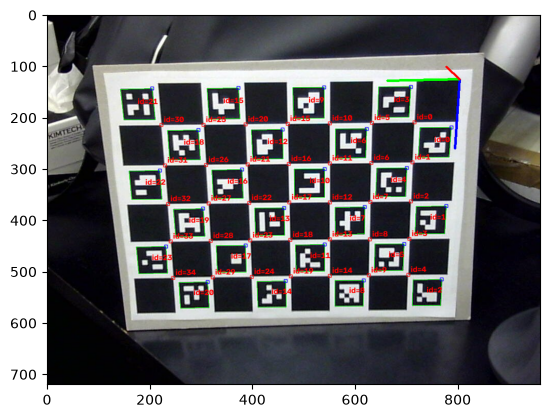

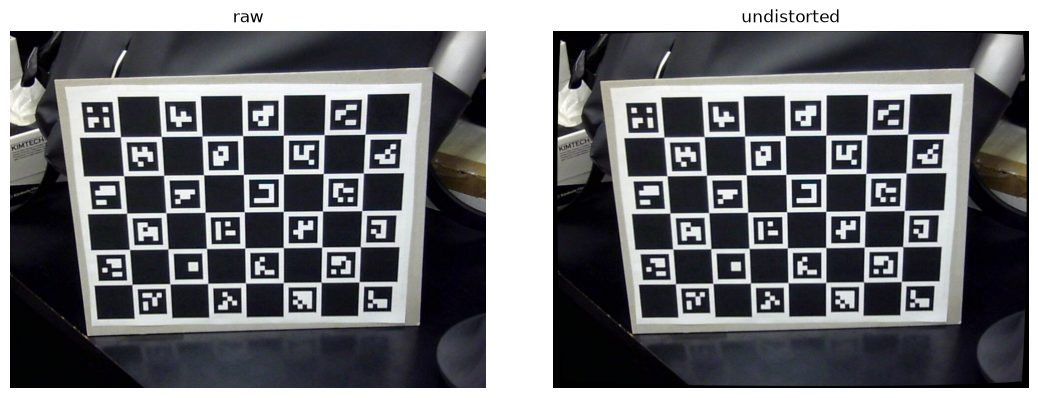

In [5]:
# Sanity check: board pose on one view + before/after undistortion
img_rgb = cv2.cvtColor(cv2.imread(image_files[1]), cv2.COLOR_BGR2RGB)
ok, rvec, tvec, drawn = detect_calib_board(img_rgb, camera_matrix, distortion_coefficients)

undistorted = cv2.undistort(img_rgb, camera_matrix, distortion_coefficients)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].imshow(img_rgb);      ax[0].set_title("raw");         ax[0].axis("off")
ax[1].imshow(undistorted);  ax[1].set_title("undistorted"); ax[1].axis("off")
plt.tight_layout(); plt.show()

In [6]:
# Colour segmentation in HSV.
#
# OpenCV hue is 0-179 (degrees / 2), S and V are 0-255. The S/V floors are what
# keep white walls and dark corners out of the mask - tune those before hue.
# Red straddles hue 0, so it needs two windows OR'd together; green and blue
# sit mid-range and need only one.
HSV_RANGES = {
    "red":   [((  0, 120, 70), ( 10, 255, 255)),    # low side of the wrap
              ((170, 120, 70), (179, 255, 255))],   # high side
    "green": [(( 40,  80, 60), ( 85, 255, 255))],
    "blue":  [((100,  80, 60), (130, 255, 255))],
}

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

def colour_mask(frame_bgr, colour):
    """Binary mask (0 / 255) of one named colour in HSV_RANGES."""
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    mask = None
    for lo, hi in HSV_RANGES[colour]:
        m = cv2.inRange(hsv, np.array(lo, np.uint8), np.array(hi, np.uint8))
        mask = m if mask is None else cv2.bitwise_or(mask, m)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)    # drop speckle
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)   # fill pinholes
    return mask

def largest_blob(mask, min_area=200):
    """Biggest contour in a mask, or None. This is what you feed to the SVD pose cell."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    cnt = max(contours, key=cv2.contourArea)
    return cnt if cv2.contourArea(cnt) >= min_area else None

In [7]:
# Live three-colour view: original + R/G/B masks tiled in one window.
# Each mask is tinted its own colour so you can tell at a glance which is which.
TINTS = {"red": (0, 0, 255), "green": (0, 255, 0), "blue": (255, 0, 0)}   # BGR

img = Image.open('./drone_orientation/drone1.jpeg')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
cv2.imshow('Image Window', hsv)


error: OpenCV(5.0.0) :-1: error: (-5:Bad argument) in function 'cvtColor'
> Overload resolution failed:
>  - src is not a numpy array, neither a scalar
>  - Expected Ptr<cv::UMat> for argument 'src'


In [ ]:
# Tuner: LEFT-click your object in the live feed to read its HSV, then widen
# HSV_RANGES around what you see. Beats guessing numbers.
#   left click  = sample the 5x5 patch under the cursor
#   right click = clear samples (do this between red and green)
#   ESC         = close and print the summary
# Right-click also pops HighGUI's own Qt context menu - harmless, dismiss it.
samples = []

def on_click(event, x, y, flags, hsv_holder):
    hsv = hsv_holder[0]
    if hsv is None:
        return
    if event == cv2.EVENT_LBUTTONDOWN:
        patch = hsv[max(y-2, 0):y+3, max(x-2, 0):x+3].reshape(-1, 3)
        h, s, v = patch.mean(axis=0)
        samples.append((h, s, v))
        print("[{0:2d}] H={1:5.1f}  S={2:5.1f}  V={3:5.1f}".format(len(samples), h, s, v))
    elif event == cv2.EVENT_RBUTTONDOWN:
        samples.clear()
        print("-- samples cleared --")

cap = open_camera()
hsv_holder = [None]
cv2.namedWindow("click to sample")
cv2.setMouseCallback("click to sample", on_click, hsv_holder)
while True:
    ret, frame = cap.read()
    if not ret:
        break
    hsv_holder[0] = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    # Echo recent samples onto the frame too - a callback's print() can be
    # swallowed while the cell is mid-loop.
    for i, (h, s, v) in enumerate(samples[-6:]):
        cv2.putText(frame, "H{0:.0f} S{1:.0f} V{2:.0f}".format(h, s, v),
                    (8, 20 + 18 * i), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    cv2.imshow("click to sample", frame)
    if cv2.waitKey(1) & 0xFF == 27:  # ESC
        break
cap.release()
cv2.destroyAllWindows()

if samples:
    arr = np.array(samples)
    lo, hi = arr.min(axis=0), arr.max(axis=0)
    print("\n{0} samples".format(len(arr)))
    print("  H {0:.0f}-{1:.0f}   S {2:.0f}-{3:.0f}   V {4:.0f}-{5:.0f}".format(
        lo[0], hi[0], lo[1], hi[1], lo[2], hi[2]))
    print("  suggested: (({0:.0f}, {1:.0f}, {2:.0f}), ({3:.0f}, 255, 255))".format(
        max(lo[0] - 10, 0), max(lo[1] - 30, 0), max(lo[2] - 30, 0), min(hi[0] + 10, 179)))
    print("  (red wraps at 0/179 - if samples straddle both ends, split into two ranges)")

In [ ]:
# Live SVD drone pose estimator
cap = open_camera()
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (12, 12))
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, 90, 255, cv2.THRESH_BINARY)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt = max(contours, key=cv2.contourArea) # pick largest contour by area

        M = cv2.moments(cnt) # contour centroid
        if M["m00"] != 0:
            centroid_x = int(M["m10"] / M["m00"])
            centroid_y = int(M["m01"] / M["m00"])
        else:
            centroid_x = centroid_y = None

        print("centroid:", (centroid_x, centroid_y))

        if cv2.contourArea(cnt) > 200:
            fill = np.zeros_like(gray)
            cv2.drawContours(fill, [cnt], -1, 255, cv2.FILLED)
            ys, xs = np.nonzero(fill)
            pts = np.column_stack((xs, ys)).astype(float)
            center = pts.mean(axis=0)
            _, S, Vt = np.linalg.svd(pts - center, full_matrices=False)
            major = Vt[0]                                  # in-plane axis (image coords)
            alpha = np.arccos(np.clip(S[1] / S[0], 0, 1))  # tilt: minor/major = cos(alpha)
            normal = np.array([-np.sin(alpha) * major[1],  # disk-plane normal (3D)
                                np.sin(alpha) * major[0],
                                np.cos(alpha)])
            proj = (pts - center) @ major
            L = (proj.max() - proj.min()) / 2              # draw length from blob extent
            c = center.astype(int)
            cv2.line(frame, tuple((center - major * L).astype(int)),
                            tuple((center + major * L).astype(int)), (255, 0, 0), 2)
            cv2.line(frame, tuple(c),
                            tuple((center + normal[:2] * L).astype(int)), (0, 255, 0), 2)
            cv2.circle(frame, tuple(c), 4, (0, 0, 255), -1)
            image = cv2.circle(frame, (centroid_x, centroid_y), 4, (100, 0, 255), -1)


    cv2.imshow("pose", frame)
    if cv2.waitKey(1) & 0xFF == 27:  # ESC
        break
cap.release()
cv2.destroyAllWindows()

opened /dev/video6: Dino-Lite Premier: Dino-Lite Pr
centroid: (290, 266)
centroid: (291, 266)
centroid: (291, 266)
centroid: (291, 266)
centroid: (291, 266)
centroid: (291, 266)
centroid: (290, 267)
centroid: (291, 266)
centroid: (290, 266)
centroid: (291, 266)
centroid: (290, 266)
centroid: (285, 268)
centroid: (291, 266)
centroid: (291, 266)
centroid: (286, 268)
centroid: (290, 266)
centroid: (291, 266)
centroid: (285, 268)
centroid: (291, 266)
centroid: (291, 266)
centroid: (291, 266)
centroid: (292, 266)
centroid: (286, 268)
centroid: (290, 267)
centroid: (291, 267)
centroid: (295, 267)
centroid: (290, 267)
centroid: (285, 268)
centroid: (292, 266)
centroid: (291, 266)
centroid: (286, 268)
centroid: (285, 268)
centroid: (286, 268)
centroid: (282, 270)
centroid: (285, 268)
centroid: (285, 269)
centroid: (291, 267)
centroid: (285, 269)
centroid: (291, 266)
centroid: (289, 269)
centroid: (291, 267)
centroid: (286, 268)
centroid: (291, 267)
centroid: (292, 267)
centroid: (290, 269)
cen

KeyboardInterrupt: 